corresponding to archive-46

In [3]:
import pickle
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import math

ub:ub7ma-, mean:3.4927254092352733
ub:ub7ma, mean:7.555086037312235
ub:ub11, mean:7.906369193690164
ub:ub11m, mean:11.793283801862172
count:1/5 youtube_1000_T.pdf completed.
count:2/5 youtube_v.jpg completed.
count:3/5 youtube_v.jpg completed.


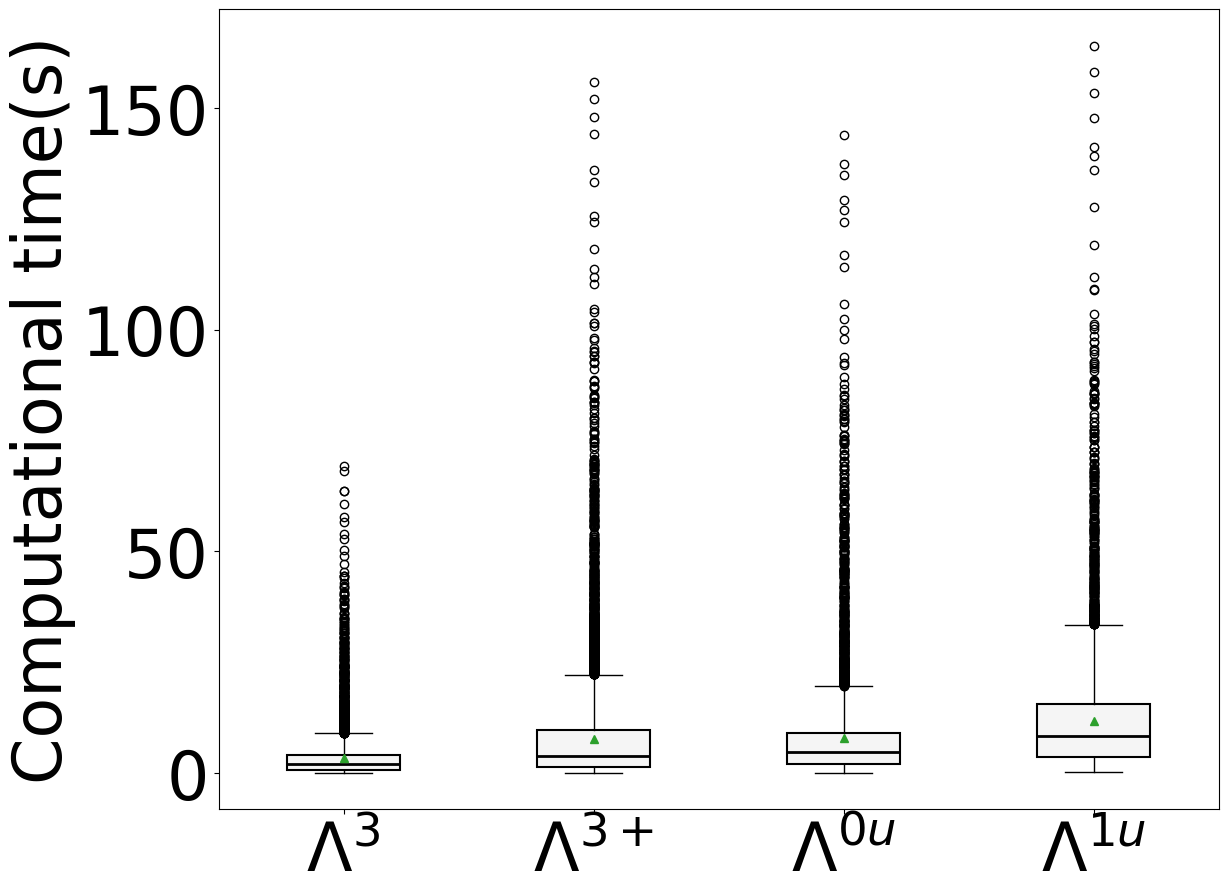

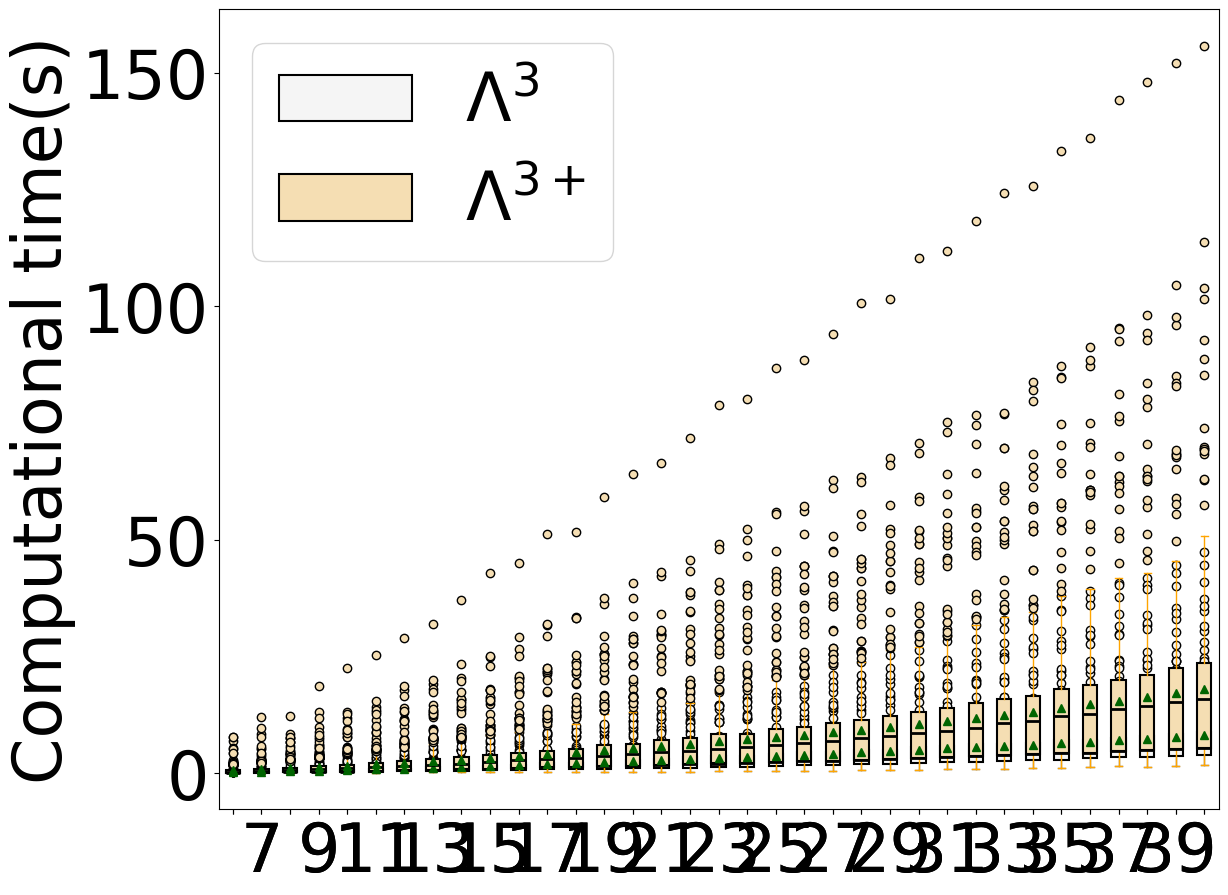

In [14]:
t = True

def load_12_series(upper_bound: str, task_name: str, source_dir: str):
    """
    kv_data has the following keys: 
    - 'S'
    - 'f(S)'
    - 'c(S)'
    - 'Lambda'
    - 'AF'
    """
    task_dict = {
        "facebook": "FacebookGraphCoverage",
        "youtube" : "YoutubeCoverage",
        "caltech": "CalTechMaximization",
        "adult": "AdultIncomeFeatureSelection"
    }

    res = []
    # print(f"r:{source_dir}")
    for name in os.listdir(source_dir):
        # print(f"name:{name}")
        if not os.path.isdir(os.path.join(source_dir, name)):
            algo, up, task, budget = name.strip()[:-5].split('-')
            if up == upper_bound and task_dict[task_name] == task:
                # print(name)
                file_path = os.path.join(source_dir, name)
                with open(file_path, "rb") as rd:
                    kv_data = pickle.load(rd)
                # print(kv_data)
                if t:
                    res.append( (eval(budget), kv_data['f(S)'], kv_data['Lambda'], kv_data['Time']))
                else:
                    res.append( (eval(budget), kv_data['f(S)'], kv_data['Lambda'], kv_data['AF']))
            elif up == 'ub7ma' and upper_bound == 'ub7ma-' and algo == 'modified_greedy_nis':
                file_path = os.path.join(source_dir, name)
                with open(file_path, "rb") as rd:
                    kv_data = pickle.load(rd)
                # print(kv_data)
                if t:
                    res.append( (eval(budget), kv_data['f(S)'], kv_data['Lambda'], kv_data['Time']))
                else:
                    res.append( (eval(budget), kv_data['f(S)'], kv_data['Lambda'], kv_data['AF']))
    res = sorted(res, key=lambda x: x[0])
    # print(res)
    X, Y, Z, W = list(zip(*res))   # change it to two columns
    return X, Y, Z, W

task_list = ['youtube']

ub_list = [
    'ub7ma-', 'ub7ma', 'ub11', 'ub11m'
]

ub_title_dict = {
    'ub1': r"$\Lambda^{0}$", 
    'ub1ma': r"$\Lambda^{1}$", 
    'ub7': r"$\Lambda^{2}$", 
    'ub7ma-': r"$\Lambda^{3}$", 
    'ub7ma': r"$\Lambda^{3+}$", 
    'ub11': r"$\Lambda^{0u}$", 
    'ub11m': r"$\Lambda^{1u}$", 
}

ub_title_list = [ub_title_dict[ub] for ub in ub_list]

archive_dir = "../result/archive-50"

result_dir = "./result_33+0u1u"

n = 1000
worst_case = math.log(n, math.e)
fs = 48

u_data_list = []
for ub in ub_list:
    u_data_list.append([])

seed_range = range(0, 200)
b_range = range(6, 41)

b_data_list = []
for ub in ub_list:
    temp = []
    for v in b_range:
        temp.append([])
    b_data_list.append(temp)
bti_dict = {}
for i in range(0, len(b_range)):
    b = float(b_range[i])
    bti_dict[b] = i

ub_to_draw_list = [0, 1]

count = 0
total_count = len(task_list) + len(ub_list) * len(task_list)

for task in task_list:
    for seed in seed_range:
        for ub_idx in range(0, len(ub_list)):
            # print(f"seed:{seed}")
            ub = ub_list[ub_idx]
            source_dir = os.path.join(archive_dir, f"{task}", f"{n}", f"{seed}")
            # print(f"seed:{seed}")
            X, Y, Z, W = load_12_series(upper_bound=ub, task_name=task, source_dir=source_dir)

            for x_idx in range(0, len(X)):
                b = X[x_idx]
                b_list_idx = bti_dict[b]
                b_data_list[ub_idx][b_list_idx].append(W[x_idx])    
                u_data_list[ub_idx].append(W[x_idx])

    # first plot
    data = u_data_list

    plt.rcParams["font.size"] = fs
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_axes([0,0,1,1])
    if t:
        ax.set_ylabel("Computational time(s)")
    else:
        ax.set_ylabel("Approximation factor")

    box_props = dict(linewidth=1.5, color="black")
    median_props = dict(linewidth=2)

    for ub_idx in range(0, len(ub_list)):
        ub = ub_list[ub_idx]
        print(f"ub:{ub}, mean:{np.mean(data[ub_idx])}")

    bp = ax.boxplot(data, patch_artist=True, showfliers=True, tick_labels=ub_title_list, showmeans=True, boxprops=box_props, medianprops=median_props)
    # plt.axhline(y = worst_case, color = 'r', linestyle = '-') 
    
    ax.plot()

    plt.xticks(fontsize=fs) 

    for median in bp["medians"]:
        median.set_color("black")

    for box in bp["boxes"]:
        box.set_facecolor("whitesmoke")


    suffix=""
    if t:
        suffix="_T"
    else:
        suffix=""

    plt.savefig(os.path.join(result_dir, f"{task}_{n}{suffix}.pdf"), format='pdf', bbox_inches='tight')
    plt.savefig(os.path.join(result_dir, f"{task}_{n}{suffix}.jpg"), format='jpg', bbox_inches='tight')
    count = count + 1
    print(f"count:{count}/{total_count} {task}_{n}{suffix}.pdf completed.")

    # second plot

    fig = plt.figure(figsize=(10, 8))

    ax = fig.add_axes([0,0,1,1])
    if t:
        ax.set_ylabel("Computational time(s)")
    else:
        ax.set_ylabel("Approximation factor")


    box_props = dict(linewidth=1.5, color="black")
    median_props = dict(linewidth=2)
    mean_props = {"marker":"^","markerfacecolor":"darkgreen", "markeredgecolor":"darkgreen"}
    flier_props = {"marker":"o","markerfacecolor":"darkgreen", "markeredgecolor":"black"}
    flier_props = {"marker":"o","markerfacecolor":"darkgreen", "markeredgecolor":"black"}
    whisker_props = {"color":"black"}

    color_list = ["whitesmoke","wheat", 'cornsilk']

    whisker_color_list = ["dimgray","orange",'cornsilk']
    cc = 0

    for i in ub_to_draw_list:
        data = b_data_list[i]
        ub = ub_list[i]

        flier_props["markerfacecolor"] = color_list[cc]
        whisker_props["color"] = whisker_color_list[cc]

        xtick_labels = []
        for b in b_range:
            if int(b) % 2 == 1:
                xtick_labels.append(b)
            else:
                xtick_labels.append(" ")

        bp = ax.boxplot(data,label=ub_title_dict[ub], patch_artist=True, tick_labels=xtick_labels, showmeans=True, boxprops=box_props, medianprops=median_props
                        , meanprops=mean_props, flierprops=flier_props, whiskerprops=whisker_props, capprops=whisker_props)
        # plt.axhline(y = worst_case, color = 'r', linestyle = '-') 

        for median in bp["medians"]:
            median.set_color("black")
        for box in bp["boxes"]:
            box.set_facecolor(color_list[cc])

        cc = cc + 1

        plt.legend()

        plt.savefig(os.path.join(result_dir, f"{task}_{n}_v{suffix}.jpg"), format='jpg', bbox_inches='tight')
        count = count + 1
        print(f"count:{count}/{total_count} {task}_v.jpg completed.")
    

youtube: 
ub:ub7ma-, mean:0.9610906205982844
ub:ub7ma, mean:0.961108817768305
ub:ub11, mean:0.9666062908383368
ub:ub11m, mean:0.9666062908383368
facebook:
ub:ub7ma-, mean:0.8997090620240001
ub:ub7ma, mean:0.9018033922868293
ub:ub11, mean:0.9352019579937727
ub:ub11m, mean:0.9352019579937727
adult:
ub:ub7ma-, mean:0.9327943218103186
ub:ub7ma, mean:0.9397658466777586
ub:ub11, mean:0.9287790079719588
ub:ub11m, mean:0.9287790079719588
caltech:
ub:ub7ma-, mean:0.9100773217641672
ub:ub7ma, mean:0.9370784191550733
ub:ub11, mean:0.9278032665965836
ub:ub11m, mean:0.9656158756839001

adult:
ub:ub7ma-, mean:5.172754121746336
ub:ub7ma, mean:15.610951846803937
ub:ub11, mean:7.523969499758311
ub:ub11m, mean:10.74899403166771
caltech:
ub:ub7ma-, mean:3.1488801897253307
ub:ub7ma, mean:5.536494000775473
ub:ub11, mean:5.740553117990494
ub:ub11m, mean:6.040017505884171
youtube:
ub:ub7ma-, mean:3.4927254092352733
ub:ub7ma, mean:7.555086037312235
ub:ub11, mean:7.906369193690164
ub:ub11m, mean:11.793283801862172
facebook:
ub:ub7ma-, mean:10.558673332418714
ub:ub7ma, mean:22.968542100204303
ub:ub11, mean:21.748473752771105
ub:ub11m, mean:31.993870065552848